# Lab 5: Building a Binary Classifier with PyTorch's `nn.Module`
## Breast Cancer Diagnosis Prediction

### Overview

In this lab you will build, train, and evaluate a **logistic regression classifier implemented as a
custom PyTorch `nn.Module`**. The task is real-world: given 30 numeric measurements extracted from a
digitized image of a breast mass (radius, texture, perimeter, concavity, etc.), predict whether the mass
is **Malignant (M)** or **Benign (B)**.

You will practice the *complete* end-to-end PyTorch supervised-learning workflow:

`raw tabular data → cleaning → train/test split → feature scaling → label encoding → tensors → nn.Module → training loop (forward, loss, backward, step) → evaluation → visualization`

By the end of this lab, the training loop and the custom model class should no longer feel like
"magic" — you should be able to explain *why* every line exists.

---

### Learning Objectives

By the end of this session, you will be able to:

1. **Implement a custom `nn.Module` subclass** that encapsulates learnable sub-layers (`nn.Linear`,
   `nn.Sigmoid`) and defines a `forward()` method.
2. **Trace the autograd computation graph** through a forward/backward pass and explain the role of
   `requires_grad`, `loss.backward()`, and gradient accumulation.
3. **Preprocess real-world tabular data** (scaling, label encoding, tensor conversion) so it can be
   correctly consumed by a PyTorch model — without leaking test-set information into training.
4. **Debug the most common training-loop bugs**: missing `optimizer.zero_grad()`, tensor
   shape mismatches feeding into a loss function, and forgetting `torch.no_grad()` at evaluation time.

---


## Conceptual Preparation

### 1. `nn.Module` — the building block of every PyTorch model

Every model you write in PyTorch — from a single linear layer to a 100-billion-parameter transformer —
is a subclass of `torch.nn.Module`. It gives you three things for free:

- **Encapsulation.** `__init__` is where you *declare* the layers your model owns (`nn.Linear`,
  `nn.Sigmoid`, `nn.Conv2d`, ...). Because these layers are themselves `nn.Module` instances assigned
  as attributes (`self.linear = nn.Linear(...)`), PyTorch automatically registers them as
  **sub-modules**.
- **Parameter tracking.** Every learnable weight/bias tensor inside a registered sub-module is
  automatically discoverable via `model.parameters()`. This is exactly the list the optimizer needs —
  you never manually collect weights yourself.
- **`forward()` vs. `__call__`.** You define the *computation* in `forward()`, but you never call
  `model.forward(x)` directly in practice — you call `model(x)`. `nn.Module.__call__` wraps `forward()`
  and additionally runs registered hooks (used for things like debugging, pruning, or feature
  extraction). Always prefer `model(x)` over `model.forward(x)` for this reason.

```python
class MySimpleNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()                  # MUST be called first — registers the module machinery
        self.linear = nn.Linear(num_features, 1)   # a learnable affine layer, tracked automatically
        self.sigmoid = nn.Sigmoid()                 # a stateless activation layer

    def forward(self, features):
        out = self.linear(features)
        out = self.sigmoid(out)
        return out
```


### 2. `torch.autograd` — how gradients happen automatically

Every `torch.Tensor` carries a `requires_grad` flag. Model parameters created via `nn.Linear` etc. have
`requires_grad=True` by default. As you perform operations on such tensors (`self.linear(features)`,
`self.sigmoid(out)`, the loss computation), PyTorch silently builds a **dynamic computation graph** in
the background, recording every operation and how to differentiate it.

- Calling **`loss.backward()`** walks this graph *backward* from the scalar loss value, applying the
  chain rule at every node, and accumulates the resulting gradient into the `.grad` attribute of every
  leaf tensor that has `requires_grad=True` (i.e., your model's weights and biases).
- **Gradients accumulate by default** — calling `.backward()` again *adds* to whatever is already in
  `.grad` rather than replacing it. This is why every training loop must explicitly zero the gradients
  before each new backward pass (see the pitfall box in Step 4).
- Wrapping a block in **`with torch.no_grad():`** temporarily disables graph construction — used at
  evaluation time when you only need a forward pass and want to save memory/compute.

### 3. `torch.utils.data.DataLoader` — batching, shuffling, memory efficiency

`DataLoader` wraps a `Dataset` and yields **mini-batches** during training instead of forcing you to
feed the entire dataset through the model in one forward pass:

- **Batching** — splits `N` examples into chunks of `batch_size`, so a single forward/backward pass
  only needs to hold one batch's activations in memory, not the whole dataset.
- **Shuffling** (`shuffle=True`) — reshuffles the order each epoch so the model doesn't learn spurious
  patterns from data ordering.
- **Memory efficiency** — for datasets too large to fit in memory/GPU memory at once, `DataLoader` can
  load and preprocess batches on the fly (via multiple worker processes) instead of materializing
  everything upfront.

> This lab's training loop uses **full-batch gradient descent** (the entire training set is one
> "batch"), which is why `DataLoader` is not used below — it fits easily in memory (455 rows × 30
> features). The **bonus challenge** at the end asks you to convert this into mini-batch training with
> a real `DataLoader`, which is where these three properties actually start to matter.


### The Math Behind This Lab

**1. Linear (affine) transformation** — what `nn.Linear(num_features, 1)` computes for each example
$x \in \mathbb{R}^{30}$:

$$z = w^\top x + b, \qquad w \in \mathbb{R}^{30},\ b \in \mathbb{R}$$

**2. Sigmoid activation** — squashes the raw score $z$ into a probability in $(0, 1)$:

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

**3. Binary Cross-Entropy Loss** — measures how far the predicted probability $\hat{y}$ is from the
true label $y \in \{0, 1\}$, averaged over the $N$ examples in the batch:

$$\mathbf{Loss} = -\frac{1}{N}\sum_{i=1}^{N} \Big[\, y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \,\Big]$$

**4. SGD parameter update** — after `loss.backward()` populates `.grad` for every parameter $\theta$
(i.e. every entry of $w$ and $b$), `optimizer.step()` applies:

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}$$

where $\eta$ is the learning rate (`learning_rate = 0.1` below).


## Deep Learning Training Pipeline

1. **Load the dataset**
2. **Basic preprocessing**
3. **Training Process**
   - a. Create the model
   - b. Forward pass
   - c. Loss calculation
   - d. Backprop
   - e. Parameters update
4. **Model evaluation**

---
## Step 1: Environment & Hyperparameters


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

---
## Step 2: Data Ingestion & Preprocessing

We use the **Wisconsin Breast Cancer diagnostic dataset**: 569 patient records, 30 numeric features
computed from a digitized image of a fine needle aspirate (FNA) of a breast mass, and a `diagnosis`
label of `M` (malignant) or `B` (benign).


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.shape

(569, 33)

In [ ]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)
df.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.shape

(569, 31)

In [ ]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

### Train/test split

We hold out 20% of the data as a test set **before** any scaling or encoding happens, so that no
information from the test set leaks into how we fit our preprocessing steps.


### Feature scaling

`nn.Linear` + `nn.Sigmoid` + gradient descent all train far more reliably when input features are on
comparable scales (compare `radius_mean` ≈ 10–30 vs. `area_mean` ≈ 150–2500 in the raw data).
`StandardScaler` rescales every feature to zero mean, unit variance: $x' = \frac{x - \mu}{\sigma}$.




In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
X_train


array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

### Label encoding

The target column currently holds the strings `'M'` and `'B'`. `LabelEncoder` maps these to integers
(alphabetically: `B` → 0, `M` → 1) so they can become numeric tensors. As with the scaler, we `fit` only
on the training labels and `transform` the test labels using that same mapping.


In [ ]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)
y_train


array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,

### NumPy arrays → PyTorch tensors

>  **Common Pitfall: dtype mismatch (`Double` vs. `Float`).**
> NumPy's default floating-point dtype is `float64` ("double"), but PyTorch's `nn.Linear` weights are
> `float32` ("float") by default. Feeding a `float64` tensor into a `float32` layer raises
> `RuntimeError: expected scalar type Float but found Double`. That's why every array below is cast
> with `.astype(np.float32)` **before** `torch.from_numpy(...)`.

**Shapes to keep in mind:**
- `X_train_tensor`: `(num_train_samples, 30)`
- `y_train_tensor`: `(num_train_samples,)` — a **1-D** tensor. Our model, however, will output shape
  `(num_train_samples, 1)`. This mismatch matters later when we compute the loss — watch for it in
  Step 4.


In [ ]:
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.astype(np.float32))
y_test_tensor = torch.from_numpy(y_test.astype(np.float32))

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)


X_train_tensor: torch.Size([455, 30])
y_train_tensor: torch.Size([455])


---
## Step 3: Model Architecture (Custom `nn.Module`)

Now define the classifier itself: a single `nn.Linear` layer (logistic regression) followed by a
`nn.Sigmoid` activation to turn the raw score into a probability.

> **Common Pitfall: mismatched layer dimensions.**
> `nn.Linear(in_features, out_features)` — `in_features` **must** equal the number of columns in your
> input tensor (here, `X_train_tensor.shape[1] == 30`), or you'll get a matrix-multiplication shape
> error at the very first forward pass. `out_features = 1` because this is **binary** classification —
> we only need one probability (P(malignant)) per example, not one score per class.


In [ ]:
class MySimpleNN(nn.Module):

  def __init__(self, num_features):
    super().__init__()

    # Input:  (Batch_Size, num_features)  ->  Output: (Batch_Size, 1)
    self.linear = nn.Linear(num_features, 1)

    # squashes the raw score into a probability in (0, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):
    # features: (Batch_Size, num_features)
    out = self.linear(features)
    out = self.sigmoid(out)
    return out


### Hyperparameters & loss function


In [ ]:
learning_rate = 0.1
epochs = 25


In [ ]:
# Binary Cross-Entropy loss (see the formula above) — expects both prediction and
# target to be the SAME shape, e.g. (N, 1).
loss_function = nn.BCELoss()


---
## Step 4: Training & Evaluation Loops

>  **Common Pitfall:**

>**`optimizer.zero_grad()` — why *before* `loss.backward()`?**
> Recall from the autograd section: gradients **accumulate** in `.grad` by default rather than being
> overwritten. If you skip `zero_grad()`, each epoch's gradient gets *added* to every previous epoch's
> gradient, and your parameter updates become increasingly wrong. The call must happen every epoch,
> before `backward()` — the exact position relative to `forward()`/`loss` computation does not matter,
> as long as it happens before `backward()` is called.


>**shape mismatch feeding `BCELoss`.**
> `y_pred` from the model has shape `(N, 1)`, but `y_train_tensor` has shape `(N,)`. `BCELoss` needs
> matching shapes, so the target is reshaped with `.view(-1, 1)` at the call site below. Forgetting
> this causes a silent **broadcasting** bug: PyTorch broadcasts `(N,)` against `(N, 1)` into an
> `(N, N)` tensor instead of raising an error, silently producing a nonsensical loss value.


In [ ]:
# create model
model = MySimpleNN(X_train_tensor.shape[1])

# define optimizer — model.parameters() automatically discovers every weight/bias
# registered by the sub-modules inside MySimpleNN (see the nn.Module conceptual section)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# track the loss at every epoch for the visualization step below
train_losses = []

for epoch in range(epochs):

  # forward pass: (N, 30) -> (N, 1)
  y_pred = model(X_train_tensor)

  # loss calculation — reshape target from (N,) to (N, 1) to match y_pred
  loss = loss_function(y_pred, y_train_tensor.view(-1, 1))

  # clear gradients from the previous iteration (see pitfall box above)
  optimizer.zero_grad()

  # backward pass — compute gradients of the loss w.r.t. every model parameter
  loss.backward()

  # parameter update step
  optimizer.step()

  train_losses.append(loss.item())
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')


Epoch: 1, Loss: 0.6703537702560425
Epoch: 2, Loss: 0.5365203022956848
Epoch: 3, Loss: 0.4555133879184723
Epoch: 4, Loss: 0.4019148647785187
Epoch: 5, Loss: 0.3638520836830139
Epoch: 6, Loss: 0.3353020250797272
Epoch: 7, Loss: 0.3129597008228302
Epoch: 8, Loss: 0.29488638043403625
Epoch: 9, Loss: 0.27987807989120483
Epoch: 10, Loss: 0.2671508193016052
Epoch: 11, Loss: 0.2561724781990051
Epoch: 12, Loss: 0.24656958878040314
Epoch: 13, Loss: 0.23807190358638763
Epoch: 14, Loss: 0.23047877848148346
Epoch: 15, Loss: 0.22363799810409546
Epoch: 16, Loss: 0.21743161976337433
Epoch: 17, Loss: 0.21176685392856598
Epoch: 18, Loss: 0.2065693885087967
Epoch: 19, Loss: 0.20177890360355377
Epoch: 20, Loss: 0.1973458230495453
Epoch: 21, Loss: 0.19322893023490906
Epoch: 22, Loss: 0.18939359486103058
Epoch: 23, Loss: 0.1858104020357132
Epoch: 24, Loss: 0.1824541687965393
Epoch: 25, Loss: 0.1793031245470047


### Evaluation

>  **Common Pitfall: forgetting `torch.no_grad()` at evaluation time.**
> Without it, every operation during evaluation still builds a computation graph for a backward pass
> you're never going to run — wasting memory and compute. `with torch.no_grad():` tells PyTorch "don't
> bother tracking gradients for anything inside this block."


In [ ]:
# model evaluation
with torch.no_grad():
  y_pred = model(X_test_tensor)

  # convert predicted probabilities into class predictions using a 0.5 threshold
  y_pred_labels = (y_pred > 0.5).float()

  # accuracy = fraction of predictions that match the true label
  # (target reshaped to (N, 1) to match y_pred_labels — same pitfall as the loss above)
  accuracy = (y_pred_labels == y_test_tensor.view(-1, 1)).float().mean()

  print(f'Accuracy: {accuracy.item()}')


Accuracy: 0.9824561476707458


---
## Step 5: Results Visualization

A falling loss curve is the first sanity check that training is actually working. Plot the
`train_losses` you collected during the training loop above.


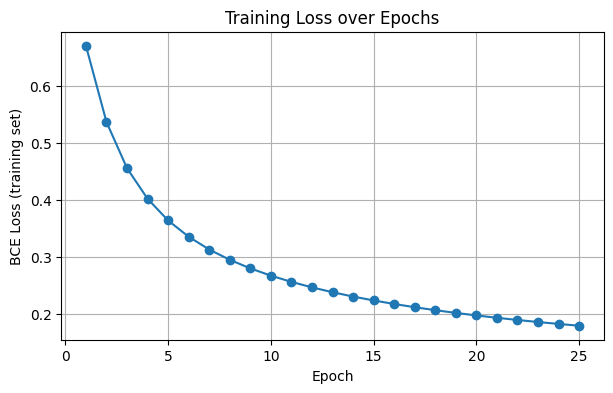

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss (training set)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()


---
## Conclusion & Reflection

### Summary

You built a complete PyTorch supervised-learning pipeline from scratch:

- Cleaned and split real tabular data, being careful to **fit preprocessing only on the training set**
  to avoid data leakage.
- Converted NumPy arrays to correctly-typed (`float32`) PyTorch tensors.
- Implemented a **custom `nn.Module`** (`MySimpleNN`) encapsulating an `nn.Linear` layer and an
  `nn.Sigmoid` activation, with the computation defined in `forward()`.
- Ran a **full-batch gradient descent** training loop: forward pass → BCE loss → `zero_grad()` →
  `backward()` → `step()`, tracking loss per epoch.
- Evaluated the trained model under `torch.no_grad()` using a 0.5 decision threshold, and visualized
  the loss curve to sanity-check convergence.

### Post-Lab Conceptual Questions

1. **Loss stability.** If you increase `epochs` well beyond 25 but keep `learning_rate = 0.1` fixed,
   what do you expect the loss curve to look like? What would you expect to happen instead if
   `learning_rate` were increased to, say, `10`, with `epochs` unchanged?
2. **Numerical stability.** This lab uses a separate `nn.Sigmoid()` layer followed by `nn.BCELoss()`.
   PyTorch also offers `nn.BCEWithLogitsLoss()`, which is applied directly to the raw linear output
   (no sigmoid layer) instead. Why is combining the sigmoid and the loss into one operation more
   numerically stable, especially when a predicted probability gets very close to 0 or 1?
3. **Full-batch vs. mini-batch.** This training loop performs **one** forward/backward pass over *all*
   455 training examples per epoch. If you instead used a `DataLoader` with `batch_size=32` (as
   described in the conceptual prep section), what would change about (a) memory usage per training
   step, (b) how "noisy" each individual gradient update is, and (c) how many parameter updates happen
   per epoch?

### Bonus / Challenge Task (optional, ~5–10 min)

Convert the training loop into **mini-batch** training using `torch.utils.data.DataLoader`:

1. Wrap `X_train_tensor` and `y_train_tensor` in a `torch.utils.data.TensorDataset`.
2. Create a `DataLoader` over that dataset with `batch_size=32` and `shuffle=True`.
3. Rewrite the training loop with a **nested** loop: for each epoch, iterate over batches from the
   `DataLoader`, running forward/loss/`zero_grad`/`backward`/`step` on each batch instead of the full
   training set at once.
4. Plot the new per-epoch average loss alongside the original full-batch curve. Does mini-batch
   training converge in fewer epochs? Is each epoch faster or slower to run?
